In [9]:
# ============================================================
# TASK 3: DATA VISUALIZATION
# Adding imports at the top of this cell too — Colab runtimes



import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os



# Quick check — make sure the cleaned CSV actually exists before we try to load it
if not os.path.exists("books_cleaned_data.csv"):
    raise FileNotFoundError(
        " 'books_cleaned_data.csv' not found!\n"
        "Please run Cells 1 through 6 first to scrape and clean the data."
    )

print(" Building our visualizations now...\n")

# Load the clean data
books_viz_df = pd.read_csv("books_cleaned_data.csv", encoding="utf-8-sig")
print(f" Loaded {len(books_viz_df)} books. Let's make some charts!")

# Setting a consistent style for all our charts
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = "Set2"

 Building our visualizations now...

 Loaded 112 books. Let's make some charts!


 Building our visualizations now...

 Chart 1: Average book price by category...


<>:43: SyntaxWarning: invalid escape sequence '\ '
<>:43: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_2518/4194527286.py:43: SyntaxWarning: invalid escape sequence '\ '
  print("   \ Chart 1 saved.\n")


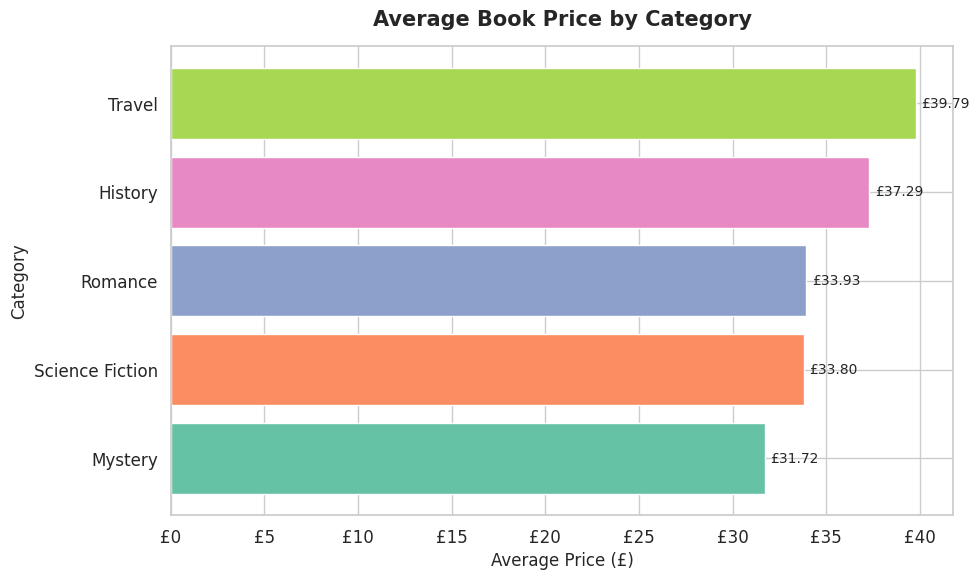

   \ Chart 1 saved.



In [10]:
# ============================================================
# TASK 3: DATA VISUALIZATION
# Let's turn our EDA findings into clear, professional charts.
# We'll make 4 visuals that tell the story of our book data.
# ============================================================

print(" Building our visualizations now...\n")

# Load the clean data
books_viz_df = pd.read_csv("books_cleaned_data.csv")

# Setting a consistent style for all our charts
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = "Set2"  # A colorblind-friendly, professional-looking palette

# --- Visualization 1: Average Price by Category (Horizontal Bar Chart) ---
print(" Chart 1: Average book price by category...")

avg_price_by_cat = books_viz_df.groupby("category")["price"].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    avg_price_by_cat.index,
    avg_price_by_cat.values,
    color=sns.color_palette(PALETTE, len(avg_price_by_cat))
)

# Adding value labels right on the bars so they're easy to read
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.3, bar.get_y() + bar.get_height() / 2,
        f"£{width:.2f}", va="center", ha="left", fontsize=10
    )

ax.set_title("Average Book Price by Category", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Average Price (£)", fontsize=12)
ax.set_ylabel("Category", fontsize=12)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("£%.0f"))
plt.tight_layout()
plt.savefig("chart1_avg_price_by_category.png", dpi=150)
plt.show()
print("   \ Chart 1 saved.\n")

 Chart 2: How ratings are distributed across all books...


/tmp/ipykernel_2518/923682718.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2518/923682718.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["⭐ (1)", "⭐⭐ (2)", "⭐⭐⭐ (3)", "⭐⭐⭐⭐ (4)", "⭐⭐⭐⭐⭐ (5)"])
/tmp/ipykernel_2518/923682718.py:25: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2518/923682718.py:26: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig("chart2_rating_distribution.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


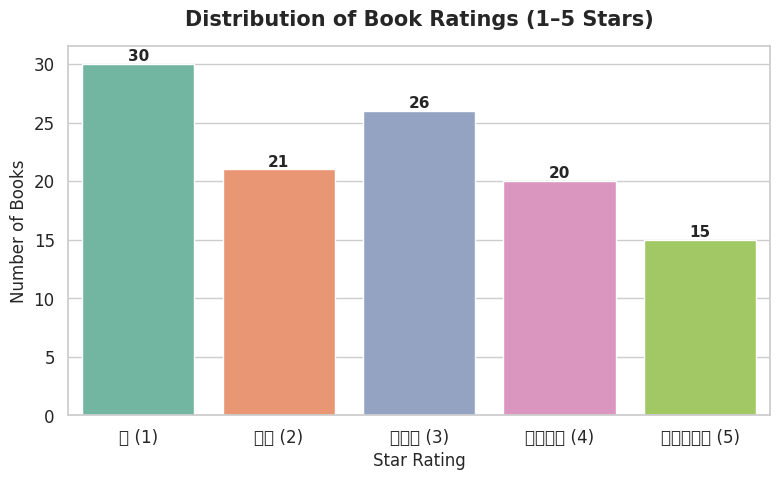

   Chart 2 saved.



In [11]:
# --- Visualization 2: Overall Rating Distribution (Count Plot) ---
print(" Chart 2: How ratings are distributed across all books...")

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    data=books_viz_df,
    x="rating",
    palette=PALETTE,
    order=[1, 2, 3, 4, 5],
    ax=ax
)

# Adding count labels on top of each bar
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Distribution of Book Ratings (1–5 Stars)", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Star Rating", fontsize=12)
ax.set_ylabel("Number of Books", fontsize=12)
ax.set_xticklabels(["⭐ (1)", "⭐⭐ (2)", "⭐⭐⭐ (3)", "⭐⭐⭐⭐ (4)", "⭐⭐⭐⭐⭐ (5)"])
plt.tight_layout()
plt.savefig("chart2_rating_distribution.png", dpi=150)
plt.show()
print("   Chart 2 saved.\n")

 Chart 3: Does price predict a better rating? Let's see...


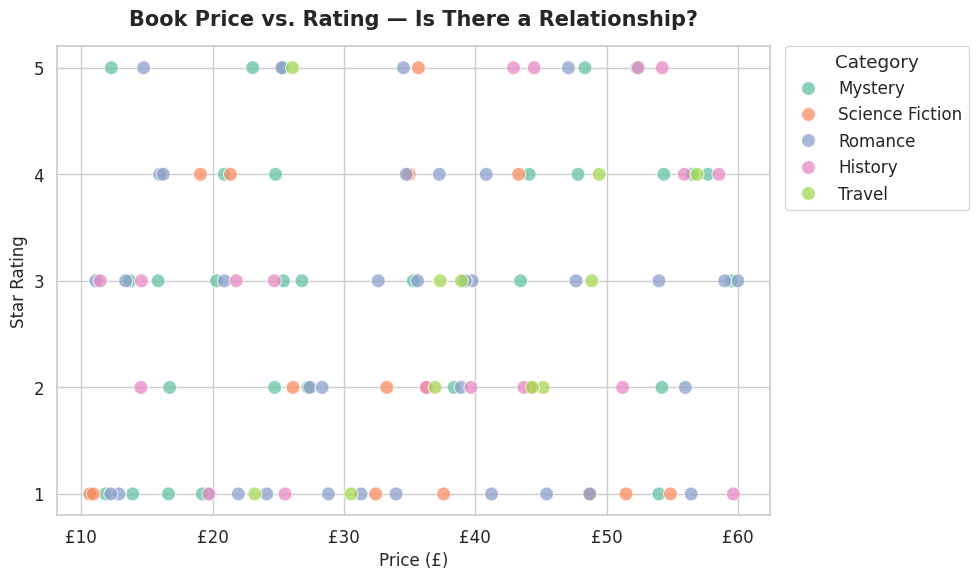

    Chart 3 saved.



In [12]:
# --- Visualization 3: Price vs Rating Scatter Plot ---
print(" Chart 3: Does price predict a better rating? Let's see...")

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=books_viz_df,
    x="price",
    y="rating",
    hue="category",
    palette=PALETTE,
    s=100,         # Dot size
    alpha=0.75,    # Slight transparency so overlapping dots show up
    ax=ax
)

ax.set_title("Book Price vs. Rating — Is There a Relationship?", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Price (£)", fontsize=12)
ax.set_ylabel("Star Rating", fontsize=12)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("£%.0f"))
ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.savefig("chart3_price_vs_rating.png", dpi=150, bbox_inches="tight")
plt.show()
print("    Chart 3 saved.\n")

 Chart 4: How does price vary within each category?


/tmp/ipykernel_2518/586757061.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


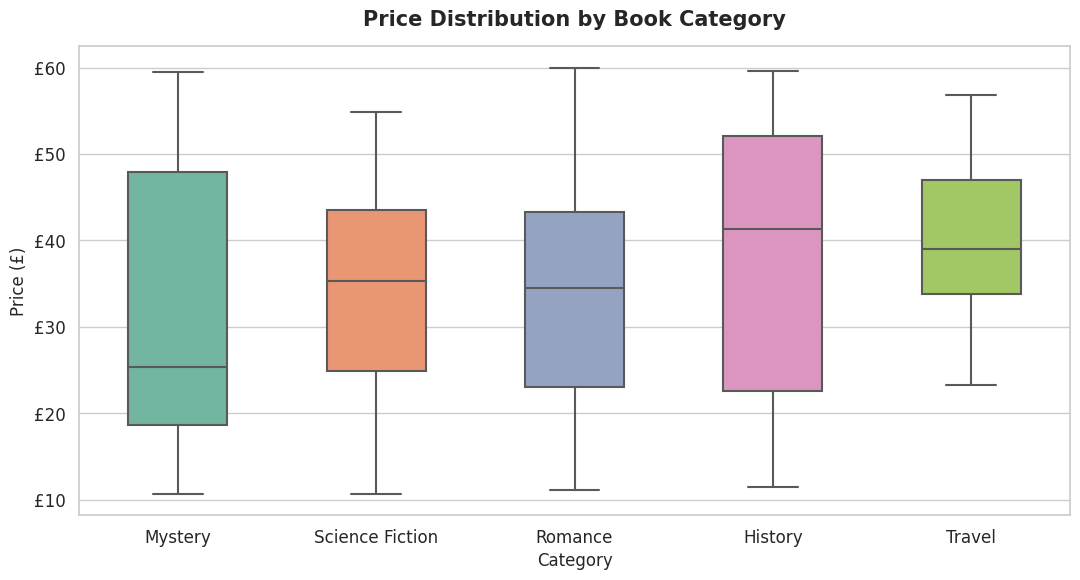

    Chart 4 saved.

 All visualizations complete! Charts saved as PNG files in your Colab environment.


In [13]:
# --- Visualization 4: Price Distribution by Category (Box Plot) ---
# Box plots are great for comparing spread and spotting outliers across groups
print(" Chart 4: How does price vary within each category?")

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=books_viz_df,
    x="category",
    y="price",
    palette=PALETTE,
    width=0.5,
    linewidth=1.5,
    flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 6},
    ax=ax
)

ax.set_title("Price Distribution by Book Category", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Price (£)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("£%.0f"))
plt.tight_layout()
plt.savefig("chart4_price_distribution_boxplot.png", dpi=150)
plt.show()
print("    Chart 4 saved.\n")

print(" All visualizations complete! Charts saved as PNG files in your Colab environment.")

In [14]:
# --- Final Summary ---
print("=" * 55)
print("            PROJECT SUMMARY — ALL TASKS DONE!")
print("=" * 55)
print(f"\n Files generated in this notebook:")

output_files = [
    "books_raw_data.csv",
    "books_cleaned_data.csv",
    "chart1_avg_price_by_category.png",
    "chart2_rating_distribution.png",
    "chart3_price_vs_rating.png",
    "chart4_price_distribution_boxplot.png"
]

for f in output_files:
    exists = "" if os.path.exists(f) else " Missing"
    print(f"  {exists}  {f}")

print(f"\n Final dataset stats:")
print(f"   → Total books analyzed: {books_viz_df.shape[0]}")
print(f"   → Categories covered:   {books_viz_df['category'].nunique()}")
print(f"   → Price range:          £{books_viz_df['price'].min():.2f} – £{books_viz_df['price'].max():.2f}")
print(f"   → Avg rating:           {books_viz_df['rating'].mean():.2f} ⭐")
print("\n All three tasks complete. Ready for submission!")

            PROJECT SUMMARY — ALL TASKS DONE!

 Files generated in this notebook:
    books_raw_data.csv
    books_cleaned_data.csv
    chart1_avg_price_by_category.png
    chart2_rating_distribution.png
    chart3_price_vs_rating.png
    chart4_price_distribution_boxplot.png

 Final dataset stats:
   → Total books analyzed: 112
   → Categories covered:   5
   → Price range:          £10.65 – £59.99
   → Avg rating:           2.72 ⭐

 All three tasks complete. Ready for submission!
